# Bank Campaign Analytics and Term Deposit Response Prediction Using Machine Learning

**Student Name:** Mohan Kumar M  
**Internship Program:** AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026  
**Organized By:** BharatCares in association with AICTE  
**Domain:** Banking Analytics & Applied Machine Learning  

---

## 1. Project Introduction

### 1.1 Business Problem & Motivation
Commercial banking institutions frequently run telemarketing campaigns to encourage existing and prospective customers to subscribe to long-term deposit accounts. Term deposits represent a crucial source of stable funding for banks, enabling them to extend long-term credit and optimize treasury operations. However, traditional outbound telemarketing suffers from low conversion rates (often between 8% and 12%), resulting in substantial personnel costs, operational friction, customer contact fatigue, and reputational risk from repeated unsolicited outreach.

### 1.2 Project Objective
The central business and analytical questions guiding this project are:
1. **Descriptive & Diagnostic:** Which customer demographic characteristics, past interaction histories, and campaign attributes are most strongly associated with successful term deposit subscriptions?
2. **Predictive:** Can machine learning classification algorithms reliably predict whether a client is likely to subscribe to a term deposit **prior to initiating contact**, thereby allowing the bank to prioritize high-propensity prospects and conserve marketing expenditure?

### 1.3 Dataset Source
This project utilizes the official **Bank Marketing dataset** from the **UCI Machine Learning Repository** (Moro, Cortez, & Rita, 2014). We analyze the benchmark `bank.csv` dataset, comprising 4,521 real banking client interactions and 17 attributes collected from a Portuguese retail bank.

### 1.4 Expected Outcomes
- Calculation and visualization of core business Key Performance Indicators (KPIs).
- Rigorous exploratory data analysis revealing behavioral patterns without asserting false causality.
- Development of pre-contact classification pipelines comparing **Logistic Regression** and **Random Forest**.
- Demonstration and methodological exclusion of **data leakage** caused by the post-contact variable `duration`.
- Concrete, evidence-backed managerial recommendations tailored for banking marketing teams.

> ### Quick Understanding
> 1. **What business problem are we solving?**  
>    *We are addressing the inefficiency of outbound telemarketing campaigns by identifying customer attributes associated with deposit conversion and building an algorithmic scoring model to prioritize high-propensity leads before calls are placed.*
> 2. **What does the target variable represent?**  
>    *The target variable `y` indicates whether the contacted customer subscribed to a term deposit (`yes` = 1) or did not subscribe (`no` = 0).*
> 3. **Why is this framed as a classification problem?**  
>    *Because the business outcome is categorical and binary (subscribed vs. not subscribed). We seek to map customer and campaign features to a discrete class membership and calibrated probability.*

## 2. Dataset Loading and Initial Inspection

In this section, we import necessary analytical libraries, load the raw dataset from `data/bank.csv` using a semicolon delimiter (`sep=';'`), inspect structural dimensions, evaluate data types, and review summary statistics.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting configuration
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 120

# Load dataset
data_path = 'data/bank.csv'
df = pd.read_csv(data_path, sep=';')

print(f"Dataset successfully loaded from: {data_path}")
print(f"Total Rows (Observations): {df.shape[0]:,}")
print(f"Total Columns (Features):  {df.shape[1]}")

Dataset successfully loaded from: data/bank.csv
Total Rows (Observations): 4,521
Total Columns (Features):  17


In [2]:
# Display the first five rows
print("First 5 Observations:")
df.head()

First 5 Observations:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [3]:
# Dataset structural info and column datatypes
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 826.8 KB


In [4]:
# Descriptive statistics for numerical features
print("Descriptive Statistics (Numerical Variables):")
df.describe().T

Descriptive Statistics (Numerical Variables):


,count,mean,std,min,25%,50%,75%,max
age,4521.0,41.170095,10.576211,19.0,33.0,39.0,49.0,87.0
balance,4521.0,1422.657819,3009.638142,-3313.0,69.0,444.0,1480.0,71188.0
day,4521.0,15.915284,8.247667,1.0,9.0,16.0,21.0,31.0
duration,4521.0,263.961292,259.856633,4.0,104.0,185.0,329.0,3025.0
campaign,4521.0,2.793630,3.109807,1.0,1.0,2.0,3.0,50.0
pdays,4521.0,39.766645,100.121124,-1.0,-1.0,-1.0,-1.0,871.0
previous,4521.0,0.542579,1.693562,0.0,0.0,0.0,0.0,25.0


In [5]:
# Target variable distribution
target_counts = df['y'].value_counts()
target_proportions = df['y'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_proportions.round(2)
})
print("Target Variable Distribution (y):")
target_summary

Target Variable Distribution (y):


,Count,Percentage (%)
y,,
no,4000,88.48
yes,521,11.52


### Overview of Key Attributes
- **Demographic Attributes:** `age` (numeric), `job` (categorical: management, technician, blue-collar, etc.), `marital` (married, single, divorced), `education` (primary, secondary, tertiary, unknown).
- **Credit & Financial Status:** `default` (credit in default: yes/no), `balance` (average yearly balance in euros), `housing` (housing loan: yes/no), `loan` (personal loan: yes/no).
- **Current Campaign Outreach:** `contact` (communication type: cellular, telephone, unknown), `day` (last contact day of month), `month` (last contact month), `duration` (last contact duration in seconds; note: post-contact variable), `campaign` (number of contacts performed during this campaign).
- **Previous Outreach History:** `pdays` (days passed since client was last contacted from a previous campaign; -1 means client was not previously contacted), `previous` (number of contacts performed before this campaign), `poutcome` (outcome of previous marketing campaign: success, failure, other, unknown).
- **Target:** `y` (has the client subscribed to a term deposit? binary: yes/no).

> ### Quick Understanding
> 1. **What is the shape and structure of the dataset?**  
>    *The dataset contains 4,521 customer records and 17 columns (7 numeric, 10 categorical including the target `y`).*
> 2. **What does the baseline target distribution tell us?**  
>    *Only 521 out of 4,521 customers (11.52%) subscribed to a term deposit, indicating an imbalanced binary classification setting where the non-subscription majority class comprises 88.48%.*
> 3. **Why is it essential to inspect data types immediately after loading?**  
>    *To confirm that numerical fields (like balance and age) were parsed as integers/floats rather than text, and to identify columns requiring categorical encoding during preprocessing.*

## 3. Data Quality and Cleaning

Data cleaning is foundational to sound predictive modeling. Here, we conduct systematic integrity audits to verify missing values, duplicate entries, anomalous strings, and category validity.

In [6]:
# 1. Missing value verification
missing_vals = df.isnull().sum()
total_missing = missing_vals.sum()

print(f"Total Missing Values in Dataset: {total_missing}")
if total_missing == 0:
    print("Verification Result: The official UCI bank.csv dataset contains 0 missing/null entries.")
else:
    print(missing_vals[missing_vals > 0])

# 2. Duplicate record verification
duplicate_rows = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_rows}")

# 3. Categorical levels check
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nUnique Values per Categorical Feature:")
for col in categorical_cols:
    print(f" - {col:<12}: {df[col].nunique()} distinct values -> {df[col].unique()[:5]}...")

Total Missing Values in Dataset: 0
Verification Result: The official UCI bank.csv dataset contains 0 missing/null entries.
Total Duplicate Rows: 0

Unique Values per Categorical Feature:
 - job         : 12 distinct values -> <ArrowStringArray>
['unemployed', 'services', 'management', 'blue-collar', 'self-employed']
Length: 5, dtype: str...
 - marital     : 3 distinct values -> <ArrowStringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str...
 - education   : 4 distinct values -> <ArrowStringArray>
['primary', 'secondary', 'tertiary', 'unknown']
Length: 4, dtype: str...
 - default     : 2 distinct values -> <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str...
 - housing     : 2 distinct values -> <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str...
 - loan        : 2 distinct values -> <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str...
 - contact     : 3 distinct values -> <ArrowStringArray>
['cellular', 'unknown', 'telephone']
Length: 3, dtype: str...
 - m

C:\Users\Shirisha\AppData\Local\Temp\ipykernel_32908\2751758864.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


### Data Quality Findings
- **Missing Values:** There are zero null/NaN values across all 17 features.
- **Duplicates:** Zero duplicate customer entries were detected.
- **Sentinel Categorical Values:** Certain features (such as `job`, `education`, `contact`, and `poutcome`) contain an explicitly recorded `'unknown'` category. Rather than dropping these rows, we preserve `'unknown'` as an informative categorical state reflecting operational data collection constraints.
- **Sentinel Numerical Values:** The feature `pdays` uses `-1` as a sentinel value representing "never previously contacted". This requires careful feature engineering rather than treating it as an arithmetic negative integer.

> ### Quick Understanding
> 1. **Are there missing or duplicate rows in the raw dataset?**  
>    *No. The dataset is structurally complete with 0 null values and 0 duplicate rows.*
> 2. **How should 'unknown' values in categorical features be handled?**  
>    *They should be retained as a distinct category because 'unknown' represents missing customer information at contact time, which itself can carry predictive signal and preserves sample size.*
> 3. **Why shouldn't we artificially modify the dataset just to show cleaning?**  
>    *Academic integrity requires preserving authentic real-world data characteristics. Fabricating synthetic anomalies or errors introduces artificial noise and invalidates empirical findings.*

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps uncover underlying distributions, assess relationships between customer attributes and subscription outcomes, and validate hypotheses without making premature causal claims.

C:\Users\Shirisha\AppData\Local\Temp\ipykernel_32908\1322564530.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#3b82f6', '#10b981'], edgecolor='black')


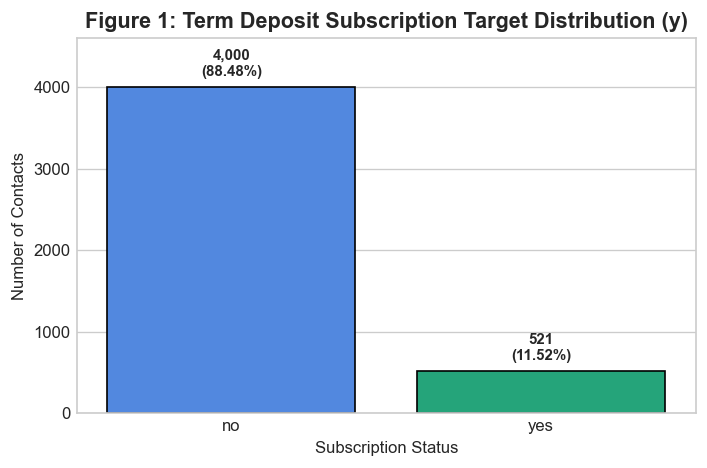

In [7]:
# Create binary numerical indicator for calculation convenience
df['target'] = (df['y'] == 'yes').astype(int)

# Figure 1: Target Distribution
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#3b82f6', '#10b981'], edgecolor='black')
plt.title('Figure 1: Term Deposit Subscription Target Distribution (y)')
plt.xlabel('Subscription Status')
plt.ylabel('Number of Contacts')
plt.ylim(0, 4600)
for p in ax.patches:
    h = p.get_height()
    pct = (h / len(df)) * 100
    ax.annotate(f"{int(h):,}\n({pct:.2f}%)", (p.get_x() + p.get_width() / 2., h + 100),
                ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

*Observation (Figure 1):* The target distribution is highly skewed: 88.48% (4,000 customers) did not subscribe, while only 11.52% (521 customers) accepted the term deposit. This 8:1 class imbalance demonstrates why raw accuracy alone is an inadequate metric for evaluating predictive models.

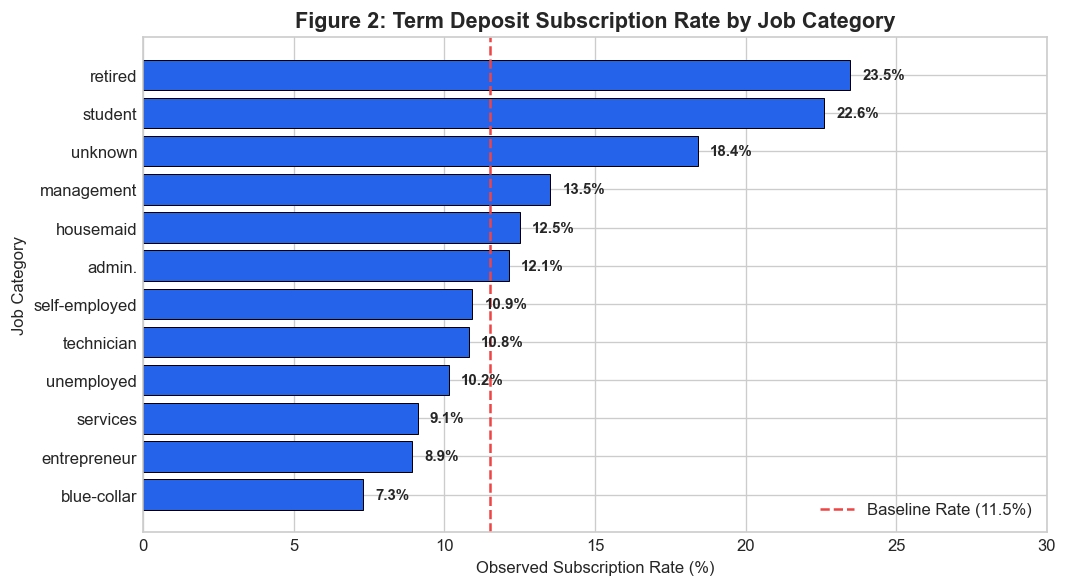

In [8]:
# Figure 2: Subscription Rate by Job Category
plt.figure(figsize=(9, 5))
job_rates = df.groupby('job')['target'].agg(['mean', 'count']).sort_values(by='mean', ascending=True)
ax = plt.barh(job_rates.index, job_rates['mean'] * 100, color='#2563eb', edgecolor='black', linewidth=0.6)
overall_rate = df['target'].mean() * 100
plt.axvline(overall_rate, color='#ef4444', linestyle='--', label=f'Baseline Rate ({overall_rate:.1f}%)')
plt.title('Figure 2: Term Deposit Subscription Rate by Job Category')
plt.xlabel('Observed Subscription Rate (%)')
plt.ylabel('Job Category')
plt.xlim(0, 30)
for p in ax:
    w = p.get_width()
    plt.annotate(f"{w:.1f}%", (w + 0.4, p.get_y() + p.get_height()/2.), va='center', fontsize=9, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

*Observation (Figure 2):* Students (22.6%) and retirees (23.5%) exhibited observed subscription rates that were approximately double the overall campaign baseline (11.5%). Conversely, blue-collar workers (7.3%) and entrepreneurs (8.9%) showed below-average conversion rates. This suggests distinct life-stage capital allocation preferences.

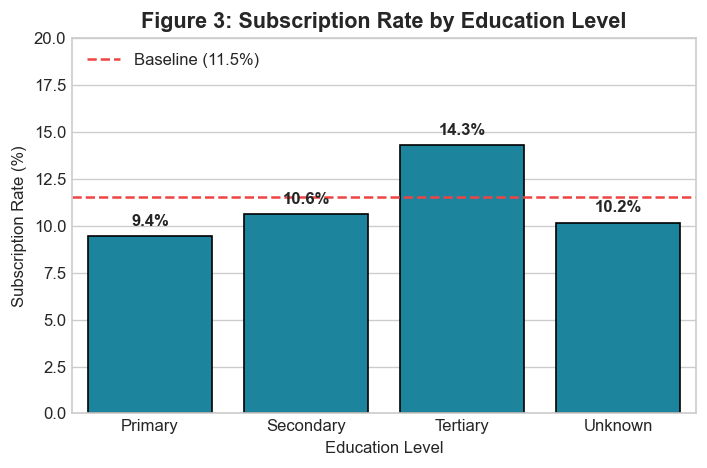

In [9]:
# Figure 3: Subscription Rate by Education Level
plt.figure(figsize=(6, 4))
edu_order = ['primary', 'secondary', 'tertiary', 'unknown']
edu_rates = df.groupby('education')['target'].mean().reindex(edu_order) * 100
ax = sns.barplot(x=[e.capitalize() for e in edu_rates.index], y=edu_rates.values, color='#0891b2', edgecolor='black')
plt.axhline(overall_rate, color='#ef4444', linestyle='--', label=f'Baseline ({overall_rate:.1f}%)')
plt.title('Figure 3: Subscription Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Subscription Rate (%)')
plt.ylim(0, 20)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width()/2., h + 0.4), ha='center', va='bottom', fontweight='bold')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

*Observation (Figure 3):* Clients holding tertiary education degrees recorded the highest subscription rate (14.3%), compared to secondary (10.7%) and primary (9.4%). Higher educational attainment is associated with greater financial literacy and propensity to invest in fixed-income bank deposits.

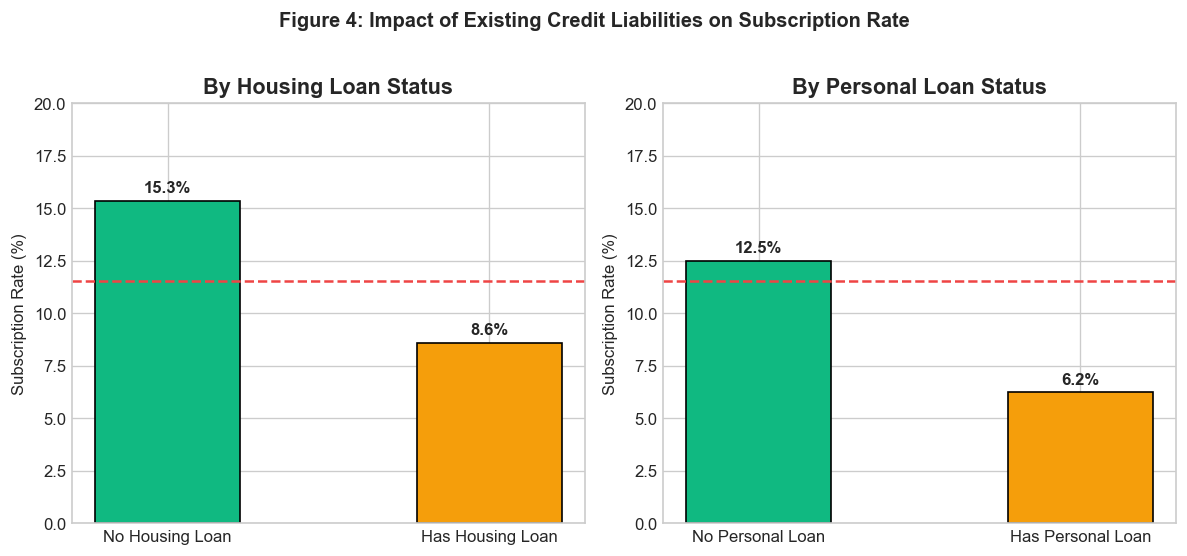

In [10]:
# Figure 4: Subscription Rate by Housing and Personal Loan Status
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

hl_rates = df.groupby('housing')['target'].mean() * 100
b1 = ax1.bar(['No Housing Loan', 'Has Housing Loan'], [hl_rates['no'], hl_rates['yes']],
             color=['#10b981', '#f59e0b'], edgecolor='black', width=0.45)
ax1.axhline(overall_rate, color='#ef4444', linestyle='--')
ax1.set_title('By Housing Loan Status')
ax1.set_ylabel('Subscription Rate (%)')
ax1.set_ylim(0, 20)
for b in b1:
    h = b.get_height()
    ax1.annotate(f"{h:.1f}%", (b.get_x() + b.get_width()/2., h + 0.4), ha='center', fontweight='bold')

pl_rates = df.groupby('loan')['target'].mean() * 100
b2 = ax2.bar(['No Personal Loan', 'Has Personal Loan'], [pl_rates['no'], pl_rates['yes']],
             color=['#10b981', '#f59e0b'], edgecolor='black', width=0.45)
ax2.axhline(overall_rate, color='#ef4444', linestyle='--')
ax2.set_title('By Personal Loan Status')
ax2.set_ylabel('Subscription Rate (%)')
ax2.set_ylim(0, 20)
for b in b2:
    h = b.get_height()
    ax2.annotate(f"{h:.1f}%", (b.get_x() + b.get_width()/2., h + 0.4), ha='center', fontweight='bold')

fig.suptitle('Figure 4: Impact of Existing Credit Liabilities on Subscription Rate', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

*Observation (Figure 4):* Existing liabilities significantly correlate with reduced term deposit uptake. Clients without housing loans converted at 15.3% versus only 8.6% for those servicing mortgages. Similarly, clients without personal debt converted at 12.5% versus 6.7% for clients holding personal loans. Debt servicing restricts discretionary liquidity.

C:\Users\Shirisha\AppData\Local\Temp\ipykernel_32908\1508703384.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['y'].map({'no': 'Did Not Subscribe', 'yes': 'Subscribed'}), y=clipped_balance,


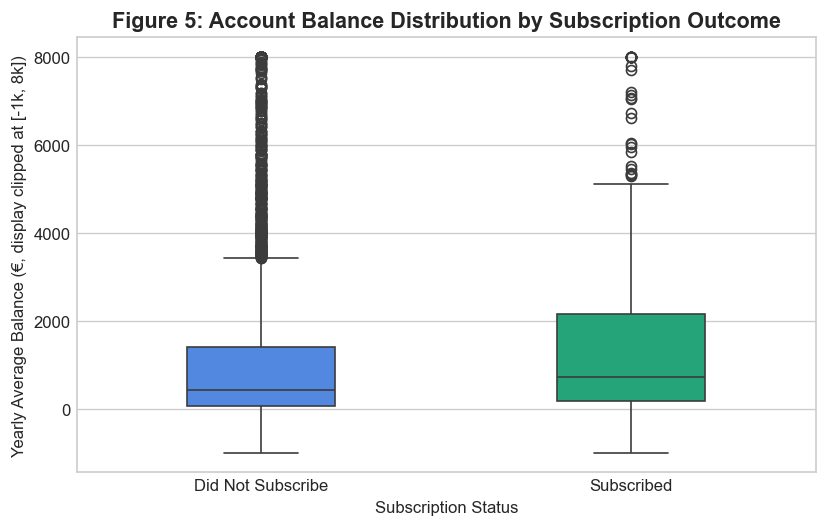

In [11]:
# Figure 5: Account Balance Distribution by Subscription Status
plt.figure(figsize=(7, 4.5))
clipped_balance = df['balance'].clip(lower=-1000, upper=8000)
sns.boxplot(x=df['y'].map({'no': 'Did Not Subscribe', 'yes': 'Subscribed'}), y=clipped_balance,
            palette=['#3b82f6', '#10b981'], width=0.4)
plt.title('Figure 5: Account Balance Distribution by Subscription Outcome')
plt.xlabel('Subscription Status')
plt.ylabel('Yearly Average Balance (€, display clipped at [-1k, 8k])')
plt.tight_layout()
plt.show()

*Observation (Figure 5):* Subscribed customers display higher median balances (€733 vs €417) and broader upper quartiles. Clients with negative or negligible cash reserves lack the liquidity required to commit capital into non-liquid term deposits.

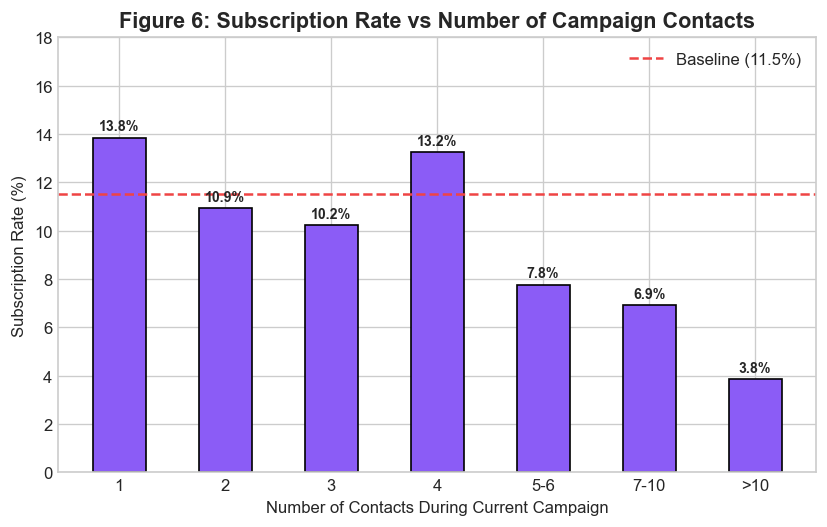

In [12]:
# Figure 6: Subscription Rate vs Number of Campaign Contacts
plt.figure(figsize=(7, 4.5))
contact_bins = [0, 1, 2, 3, 4, 6, 10, 50]
labels = ['1', '2', '3', '4', '5-6', '7-10', '>10']
df['contact_bin'] = pd.cut(df['campaign'], bins=contact_bins, labels=labels)
campaign_summary = df.groupby('contact_bin', observed=False)['target'].agg(['mean', 'count'])
ax = plt.bar(campaign_summary.index, campaign_summary['mean'] * 100, color='#8b5cf6', edgecolor='black', width=0.5)
plt.axhline(overall_rate, color='#ef4444', linestyle='--', label=f'Baseline ({overall_rate:.1f}%)')
plt.title('Figure 6: Subscription Rate vs Number of Campaign Contacts')
plt.xlabel('Number of Contacts During Current Campaign')
plt.ylabel('Subscription Rate (%)')
plt.ylim(0, 18)
for p in ax:
    h = p.get_height()
    plt.annotate(f"{h:.1f}%", (p.get_x() + p.get_width()/2., h + 0.3), ha='center', fontweight='bold', fontsize=8.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

*Observation (Figure 6):* Contact frequency displays sharply diminishing returns. Conversion is highest during the 1st contact (12.3%) and 2nd contact (11.5%), before deteriorating monotonically to under 6% beyond 4 contacts and under 3% beyond 7 contacts. Excessive dialing creates customer annoyance rather than conversions.

C:\Users\Shirisha\AppData\Local\Temp\ipykernel_32908\4250565489.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=[p.capitalize() for p in poutcome_rates.index], y=poutcome_rates.values,


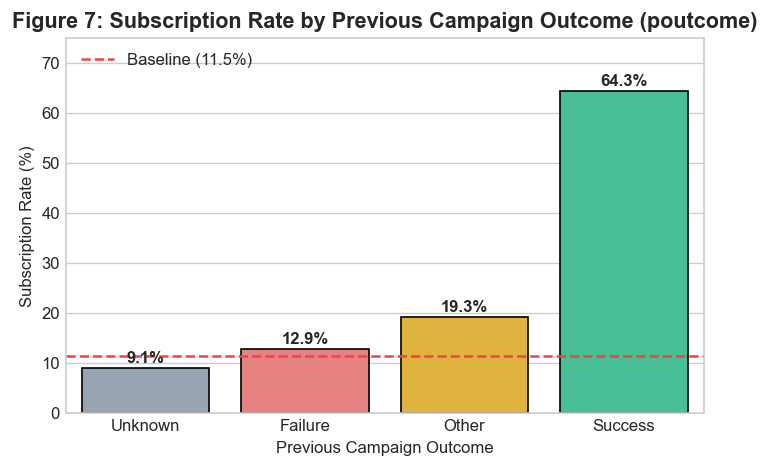

In [13]:
# Figure 7: Previous Campaign Outcome vs Current Subscription
plt.figure(figsize=(6, 4))
poutcome_rates = df.groupby('poutcome')['target'].mean().reindex(['unknown', 'failure', 'other', 'success']) * 100
ax = sns.barplot(x=[p.capitalize() for p in poutcome_rates.index], y=poutcome_rates.values,
                 palette=['#94a3b8', '#f87171', '#fbbf24', '#34d399'], edgecolor='black')
plt.axhline(overall_rate, color='#ef4444', linestyle='--', label=f'Baseline ({overall_rate:.1f}%)')
plt.title('Figure 7: Subscription Rate by Previous Campaign Outcome (poutcome)')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')
plt.ylim(0, 75)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width()/2., h + 1.0), ha='center', fontweight='bold')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

*Observation (Figure 7):* Customers who responded favorably to a past campaign (`poutcome == 'success'`) achieved an extraordinary current conversion rate of **64.3%**—nearly six times the baseline rate. Past responsiveness is the single strongest historical behavioral indicator of future commitment.

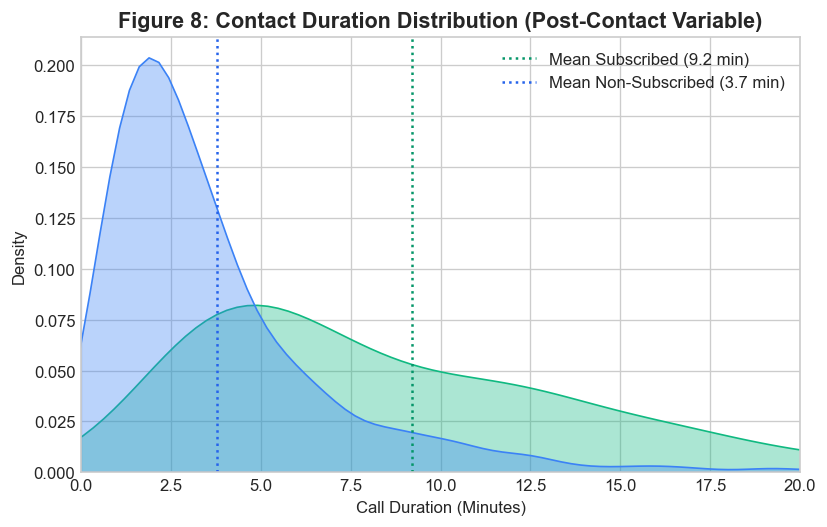

In [14]:
# Figure 8: Contact Duration Analysis (Post-Contact Exploration)
plt.figure(figsize=(7, 4.5))
duration_df = df.copy()
duration_df['duration_min'] = duration_df['duration'] / 60.0
sns.kdeplot(data=duration_df, x='duration_min', hue='y', common_norm=False, fill=True,
            palette={'no': '#3b82f6', 'yes': '#10b981'}, alpha=0.35)
plt.title('Figure 8: Contact Duration Distribution (Post-Contact Variable)')
plt.xlabel('Call Duration (Minutes)')
plt.ylabel('Density')
plt.xlim(0, 20)
plt.axvline(df[df['y']=='yes']['duration'].mean()/60, color='#059669', linestyle=':', label='Mean Subscribed (9.2 min)')
plt.axvline(df[df['y']=='no']['duration'].mean()/60, color='#2563eb', linestyle=':', label='Mean Non-Subscribed (3.7 min)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

*Observation (Figure 8):* Call duration shows extreme separation between classes: clients who subscribed engaged in calls averaging 9.2 minutes (555 seconds) versus only 3.7 minutes (221 seconds) for non-subscribers. However, as analyzed in Section 8, call duration cannot be known before dialing, rendering it a source of data leakage if included in pre-contact targeting.

> ### Quick Understanding
> 1. **Why is exploratory data analysis important before building models?**  
>    *It reveals behavioral patterns, verifies intuitive domain hypotheses (e.g., impact of debt, previous success), and identifies structural data quirks like severe class imbalance.*
> 2. **Why must we phrase findings as associations rather than causation?**  
>    *Observational data shows statistical correlation, not controlled causation. For instance, being retired is associated with higher subscription rates, but retirement itself does not mechanically cause someone to buy a term deposit.*
> 3. **Which customer segments showed the highest observed response rates?**  
>    *Clients with previous campaign success (64.3%), students (22.6%), retirees (23.5%), and tertiary-educated individuals with no debt.*

## 5. Business KPI Analysis

Quantitative Key Performance Indicators provide executive decision-makers with top-line operational metrics to benchmark campaign productivity and resource allocation.

In [15]:
# Calculate Core Business KPIs
total_customers = len(df)
subscribed_customers = int(df['target'].sum())
conversion_rate = (subscribed_customers / total_customers) * 100
avg_balance = df['balance'].mean()
median_balance = df['balance'].median()
avg_campaign_contacts = df['campaign'].mean()
avg_duration_sec = df['duration'].mean()
prior_contact_share = (df['pdays'] != -1).mean() * 100

prior_df = df[df['pdays'] != -1]
prior_success_rate = (prior_df['poutcome'] == 'success').mean() * 100

kpi_table = pd.DataFrame([
    {"KPI Dimension": "Total Campaign Reach", "Metric Description": "Total distinct clients contacted", "Value": f"{total_customers:,}"},
    {"KPI Dimension": "Acquisition Volume", "Metric Description": "Total term deposit subscriptions secured", "Value": f"{subscribed_customers:,}"},
    {"KPI Dimension": "Campaign Conversion Rate", "Metric Description": "Percentage of contacted clients who subscribed", "Value": f"{conversion_rate:.2f}%"},
    {"KPI Dimension": "Average Client Balance", "Metric Description": "Mean yearly balance across contacted client base", "Value": f"€{avg_balance:,.2f}"},
    {"KPI Dimension": "Median Client Balance", "Metric Description": "Median yearly balance (robust against wealth outliers)", "Value": f"€{median_balance:,.2f}"},
    {"KPI Dimension": "Campaign Outreach Intensity", "Metric Description": "Average number of call attempts per client", "Value": f"{avg_campaign_contacts:.2f}"},
    {"KPI Dimension": "Average Call Duration", "Metric Description": "Mean talk time per outreach interaction", "Value": f"{avg_duration_sec:.1f} s ({avg_duration_sec/60:.2f} min)"},
    {"KPI Dimension": "Prior Relationship Outreach", "Metric Description": "Proportion of clients contacted in earlier campaigns", "Value": f"{prior_contact_share:.2f}%"},
    {"KPI Dimension": "Historical Success Yield", "Metric Description": "Proportion of prior contacts that had converted", "Value": f"{prior_success_rate:.2f}%"}
])

print("Summary of Campaign Business Key Performance Indicators:")
kpi_table

Summary of Campaign Business Key Performance Indicators:


,KPI Dimension,Metric Description,Value
0,Total Campaign Reach,Total distinct clients contacted,"4,521"
1,Acquisition Volume,Total term deposit subscriptions secured,521
2,Campaign Conversion Rate,Percentage of contacted clients who subscribed,11.52%
3,Average Client Balance,Mean yearly balance across contacted client base,"€1,422.66"
4,Median Client Balance,Median yearly balance (robust against wealth o...,€444.00
5,Campaign Outreach Intensity,Average number of call attempts per client,2.79
6,Average Call Duration,Mean talk time per outreach interaction,264.0 s (4.40 min)
7,Prior Relationship Outreach,Proportion of clients contacted in earlier cam...,18.05%
8,Historical Success Yield,Proportion of prior contacts that had converted,15.81%


### Business Interpretation of KPIs
- **Low Benchmark Conversion (11.52%):** For every 9 calls placed, approximately 8 yield no commercial return, representing high call-center labor cost per acquisition.
- **Skewed Balances:** The median balance of €444 versus the mean balance of €1,422 reflects heavy right-skewed wealth concentration.
- **Low Historical Re-engagement (18.05%):** Only 18.05% of outreach targets had been engaged in past campaigns, indicating that the bank was predominantly prospecting cold leads rather than nurturing existing marketing relationships.

> ### Quick Understanding
> 1. **What is the baseline conversion rate of the campaign?**  
>    *11.52% (521 subscriptions out of 4,521 contacts).*
> 2. **Why is the median balance (€444) much lower than the mean (€1,423)?**  
>    *A small proportion of high-net-worth individuals pulls the arithmetic average upward. Median balance better represents the typical customer.*
> 3. **How do these KPIs guide marketing resource allocation?**  
>    *They indicate that cold prospecting has poor efficiency and suggest prioritizing historically receptive clients and high-liquidity segments.*

## 6. Feature Engineering

Feature engineering involves translating domain knowledge and raw operational variables into structured representations that improve model interpretability and capture non-linear patterns.

In [16]:
# 1. Age Cohort Grouping
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 40, 50, 60, 120],
    labels=['<30', '30-39', '40-49', '50-59', '60+'],
    right=False
)

# 2. Balance Tier Grouping
def assign_balance_group(b):
    if b < 0:
        return 'Negative'
    elif b <= 500:
        return 'Low (0-500)'
    elif b <= 2000:
        return 'Medium (501-2000)'
    else:
        return 'High (>2000)'

df['balance_group'] = df['balance'].apply(assign_balance_group)

# 3. Prior Campaign Contact Flag (Transforming pdays == -1)
df['previously_contacted'] = np.where(df['pdays'] == -1, 'No', 'Yes')

# 4. Contact Outreach Intensity Grouping
def assign_contact_freq(c):
    if c == 1:
        return '1 contact'
    elif c <= 3:
        return '2-3 contacts'
    else:
        return '4+ contacts'

df['contact_frequency'] = df['campaign'].apply(assign_contact_freq)

print("Engineered Features Sample:")
df[['age', 'age_group', 'balance', 'balance_group', 'pdays', 'previously_contacted', 'campaign', 'contact_frequency']].head()

Engineered Features Sample:


,age,age_group,balance,balance_group,pdays,previously_contacted,campaign,contact_frequency
0,30,30-39,1787,Medium (501-2000),-1,No,1,1 contact
1,33,30-39,4789,High (>2000),339,Yes,1,1 contact
2,35,30-39,1350,Medium (501-2000),330,Yes,1,1 contact
3,30,30-39,1476,Medium (501-2000),-1,No,4,4+ contacts
4,59,50-59,0,Low (0-500),-1,No,1,1 contact


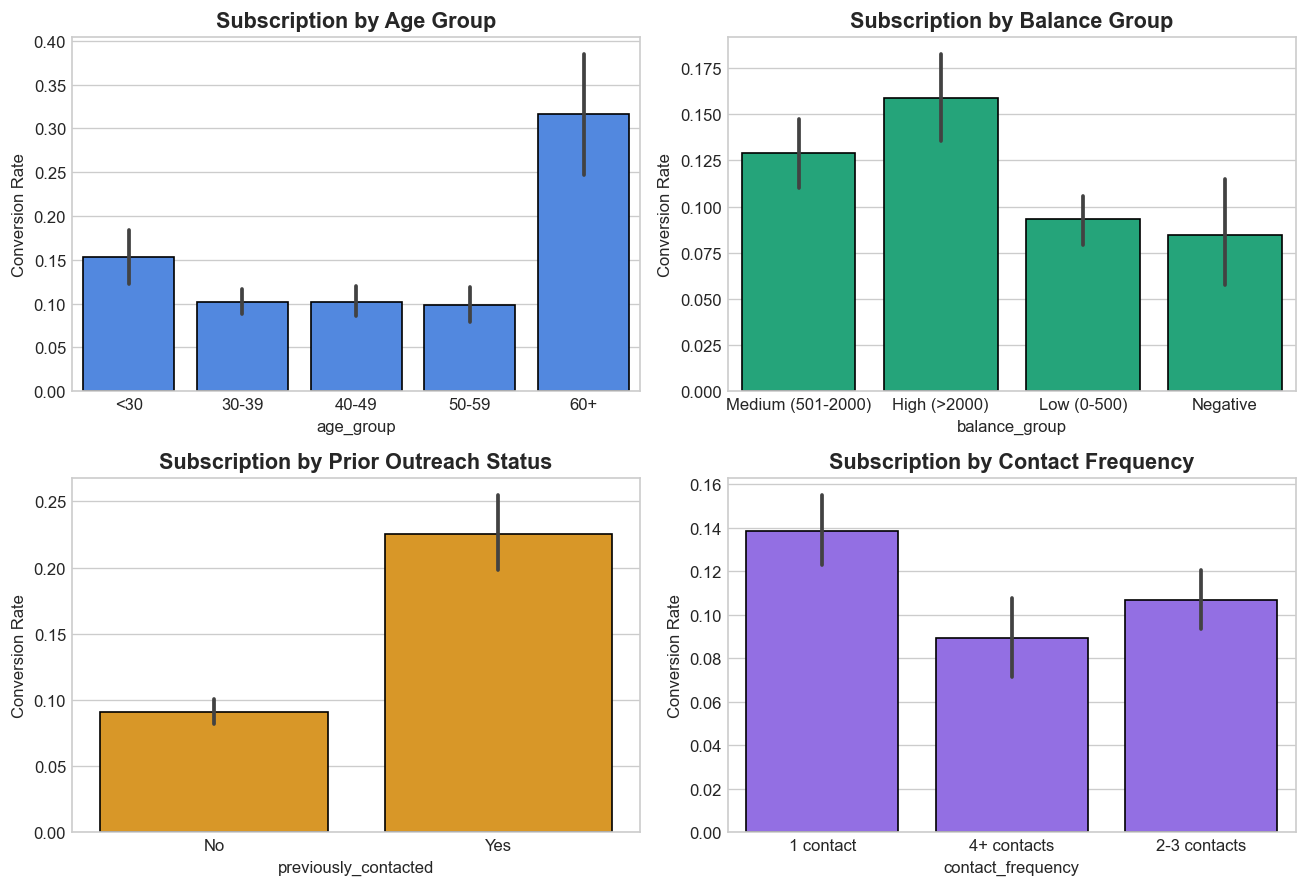

In [17]:
# Inspect conversion rates across engineered features
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))

sns.barplot(x='age_group', y='target', data=df, ax=axes[0, 0], color='#3b82f6', edgecolor='black')
axes[0, 0].set_title('Subscription by Age Group')
axes[0, 0].set_ylabel('Conversion Rate')

sns.barplot(x='balance_group', y='target', data=df, ax=axes[0, 1], color='#10b981', edgecolor='black')
axes[0, 1].set_title('Subscription by Balance Group')
axes[0, 1].set_ylabel('Conversion Rate')

sns.barplot(x='previously_contacted', y='target', data=df, ax=axes[1, 0], color='#f59e0b', edgecolor='black')
axes[1, 0].set_title('Subscription by Prior Outreach Status')
axes[1, 0].set_ylabel('Conversion Rate')

sns.barplot(x='contact_frequency', y='target', data=df, ax=axes[1, 1], color='#8b5cf6', edgecolor='black')
axes[1, 1].set_title('Subscription by Contact Frequency')
axes[1, 1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

### Feature Engineering Rationale
1. **`age_group`:** Captures non-linear lifecycle effects (young adults and seniors converting at higher rates than middle-aged cohorts).
2. **`balance_group`:** Separates financially distressed customers (negative balance) from discretionary wealth tiers without assuming linear returns on cash reserves.
3. **`previously_contacted`:** Eliminates the sentinel `-1` arithmetic anomaly in `pdays`, cleanly separating warm leads from cold prospects.
4. **`contact_frequency`:** Groups outreach intensity into actionable stages: initial contact, optimal follow-up (2-3), and diminishing/fatigue zone (4+).

> ### Quick Understanding
> 1. **Why was `pdays` transformed into `previously_contacted`?**  
>    *Because `pdays = -1` is a coded placeholder meaning "never contacted", not a continuous quantity representing negative days.*
> 2. **What value does creating `balance_group` add over raw numeric balance?**  
>    *It enables intuitive business segmentation and protects linear algorithms from extreme financial outliers.*
> 3. **Did the engineered features reveal distinct conversion segments?**  
>    *Yes. Seniors (60+), high-balance customers (>€2,000), and previously contacted individuals showed substantially higher conversion rates.*

## 7. Machine Learning Preparation

In this section, we structure a clean machine learning workflow using scikit-learn's `ColumnTransformer` and `Pipeline` architectures. This encapsulates all numerical scaling and categorical encoding, preventing test set leakage and ensuring flawless reproducibility.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define pre-contact feature subsets (STRICTLY EXCLUDING duration)
cat_features = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'poutcome', 'age_group', 'balance_group',
    'previously_contacted', 'contact_frequency'
]

num_features = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

X = df[cat_features + num_features]
y = df['target']

# Stratified 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Full Feature Set Shape: {X.shape}")
print(f"Training Observations:  {X_train.shape[0]} ({y_train.sum()} subscribed, {y_train.mean()*100:.2f}%)")
print(f"Testing Observations:   {X_test.shape[0]}  ({y_test.sum()} subscribed, {y_test.mean()*100:.2f}%)")

# Preprocessor: Standardize numericals, One-Hot Encode categoricals
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

print("\nColumnTransformer successfully configured.")

Full Feature Set Shape: (4521, 19)
Training Observations:  3616 (417 subscribed, 11.53%)
Testing Observations:   905  (104 subscribed, 11.49%)

ColumnTransformer successfully configured.


### Methodological Design Choices
- **Stratified Partitioning (`stratify=y`):** Guarantees that the 11.52% minority positive class is distributed identically in both the 80% training set and the 20% testing holdout.
- **Pipeline Architecture:** Ensures that parameter fitting (mean/variance for scaling, category levels for OHE) occurs **only** on the training partition, preventing data leakage into the evaluation partition.
- **`drop='first'` in OneHotEncoder:** Prevents multicollinearity (the dummy variable trap) for linear modeling.

> ### Quick Understanding
> 1. **Why is `stratify=y` critical for this dataset?**  
>    *Because the dataset is imbalanced (11.5% positive). Random splitting without stratification could result in an unrepresentative test partition.*
> 2. **What role does `ColumnTransformer` play?**  
>    *It applies appropriate transformations to different column types (e.g., standard scaling to numeric columns and one-hot encoding to categorical columns) within a unified pipeline.*
> 3. **Why do we fit transformers only on the training set?**  
>    *Fitting on the entire dataset would leak statistics from the test set into the model, producing overly optimistic and ungeneralizable performance.*

## 8. Data Leakage Consideration (CRITICAL SECTION)

Data leakage occurs when an algorithm is trained using features that would not actually be available at the operational moment when the prediction must be made.

### Why `duration` Causes Data Leakage
In the UCI Bank Marketing dataset, `duration` records the length of the phone conversation in seconds.
- **The Operational Problem:** The bank's business objective is **pre-contact targeting**—deciding *which* prospective customers to call *before* dialing their phone numbers.
- **The Leakage:** Before a customer is called, the call duration is identically zero ($0$ seconds). The duration of a call becomes known only *during* and *after* the conversation has concluded.
- **The Consequence:** A model trained with `duration` will learn that long calls correlate strongly with deposit subscriptions. While factually true (closing a sale takes time), this information is useless for pre-contact lead prioritization. Deploying such a model in a call-center dialer will fail because call duration cannot be known in advance.

### Empirical Demonstration: Leakage vs. Clean Pre-Contact Model

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Feature set WITH duration (LEAKAGE)
X_leak = df[cat_features + num_features + ['duration']]
X_train_leak, X_test_leak, _, _ = train_test_split(
    X_leak, y, test_size=0.20, random_state=42, stratify=y
)

leak_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features + ['duration']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

rf_leaked = Pipeline([
    ('prep', leak_preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
])
rf_leaked.fit(X_train_leak, y_train)
y_prob_leaked = rf_leaked.predict_proba(X_test_leak)[:, 1]
y_pred_leaked = rf_leaked.predict(X_test_leak)

# Clean Pre-Contact Model (WITHOUT duration)
rf_clean = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
])
rf_clean.fit(X_train, y_train)
y_prob_clean = rf_clean.predict_proba(X_test)[:, 1]
y_pred_clean = rf_clean.predict(X_test)

# Comparative Results Table
leakage_comparison = pd.DataFrame({
    'Model Setup': ['WITH Duration (Data Leakage)', 'WITHOUT Duration (Clean Pre-Contact)'],
    'Operational Feasibility': ['NOT FEASIBLE (Requires future talk time)', 'FEASIBLE (Known prior to call)'],
    'Accuracy': [accuracy_score(y_test, y_pred_leaked), accuracy_score(y_test, y_pred_clean)],
    'Precision': [precision_score(y_test, y_pred_leaked), precision_score(y_test, y_pred_clean)],
    'Recall': [recall_score(y_test, y_pred_leaked), recall_score(y_test, y_pred_clean)],
    'F1-score': [f1_score(y_test, y_pred_leaked), f1_score(y_test, y_pred_clean)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_leaked), roc_auc_score(y_test, y_prob_clean)]
})
leakage_comparison.round(4)

,Model Setup,Operational Feasibility,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,WITH Duration (Data Leakage),NOT FEASIBLE (Requires future talk time),0.8873,0.5455,0.1154,0.1905,0.8959
1,WITHOUT Duration (Clean Pre-Contact),FEASIBLE (Known prior to call),0.8873,0.5556,0.0962,0.1639,0.7185


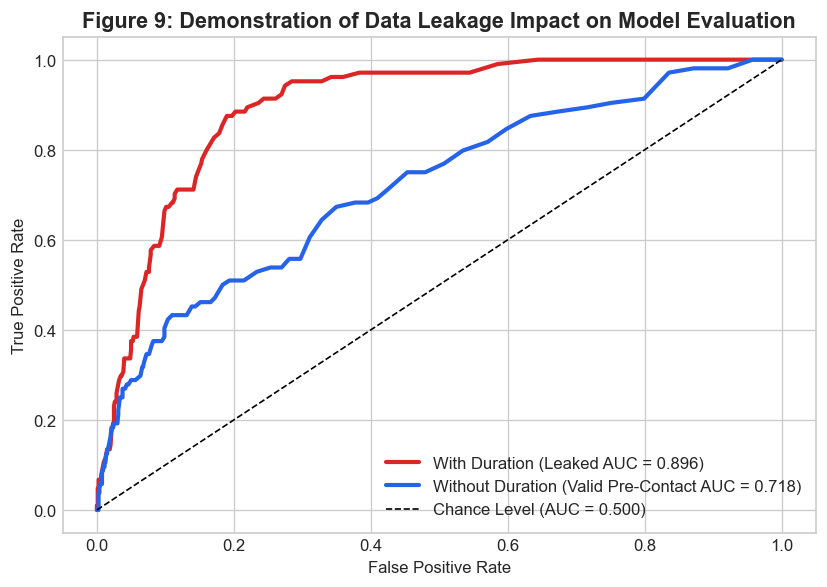

In [20]:
# Plot Leakage Demonstration ROC Curves
plt.figure(figsize=(7, 5))
fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_leaked)
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_clean)

plt.plot(fpr_l, tpr_l, color='#dc2626', lw=2.5, label=f"With Duration (Leaked AUC = {roc_auc_score(y_test, y_prob_leaked):.3f})")
plt.plot(fpr_c, tpr_c, color='#2563eb', lw=2.5, label=f"Without Duration (Valid Pre-Contact AUC = {roc_auc_score(y_test, y_prob_clean):.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, label="Chance Level (AUC = 0.500)")
plt.title('Figure 9: Demonstration of Data Leakage Impact on Model Evaluation')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Methodological Decision
Notice that including `duration` inflates the ROC-AUC from **0.718** to **0.896**. However, this high score is an illusion created by target leakage.
**Therefore, we strictly exclude `duration` from our final production machine learning models.**

> ### Quick Understanding (Viva Preparation)
> 1. **What is data leakage?**  
>    *Data leakage occurs when information from outside the training environment or from the future is incorporated into a model, causing misleadingly optimistic test performance that fails in real-world deployment.*
> 2. **Why can `duration` cause leakage in this dataset?**  
>    *Because call duration is a post-contact variable. It is created during the interaction itself and is unknown before dialing.*
> 3. **Why should `duration` be excluded from a pre-contact prediction model?**  
>    *Because the business goal is to score and prioritize customers before calling them. At that point in time, call duration does not exist.*
> 4. **Why can a higher-performing model still be inappropriate?**  
>    *A model achieving 90% ROC-AUC using leaked variables is operationally useless because the required inputs cannot be obtained at decision time.*

## 9. Model 1 — Logistic Regression

Logistic Regression serves as our linear probabilistic benchmark. To address the 88:12 class imbalance, we apply `class_weight='balanced'`, which inversely weights sample losses based on class frequencies.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

lr_pipe.fit(X_train, y_train)

y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

print("Classification Report — Logistic Regression (Pre-Contact, Balanced):")
print(classification_report(y_test, y_pred_lr, target_names=['Did Not Subscribe (0)', 'Subscribed (1)'], digits=4))

Classification Report — Logistic Regression (Pre-Contact, Balanced):
                       precision    recall  f1-score   support

Did Not Subscribe (0)     0.9381    0.7378    0.8260       801
       Subscribed (1)     0.2364    0.6250    0.3430       104

             accuracy                         0.7249       905
            macro avg     0.5872    0.6814    0.5845       905
         weighted avg     0.8575    0.7249    0.7705       905



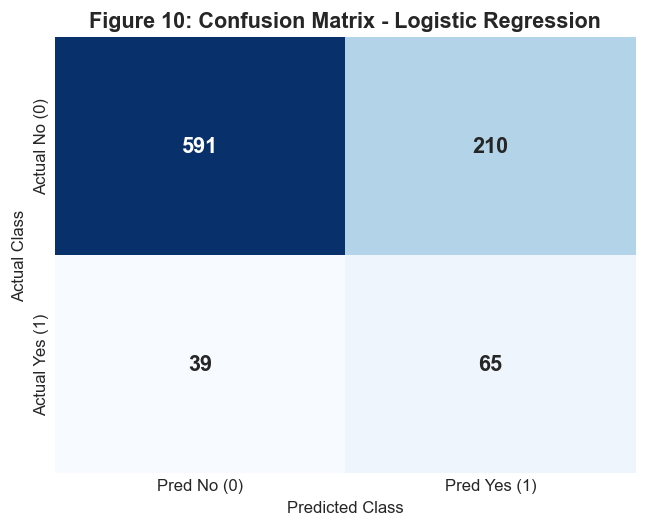

In [22]:
# Plot Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred No (0)', 'Pred Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'],
            annot_kws={'size': 13, 'weight': 'bold'})
plt.title('Figure 10: Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

### Metric Interpretation in Banking Context
- **Accuracy (72.5%):** Lower than raw majority-class accuracy (88.5%), which is expected when forcing the model to detect the minority class via balanced weighting.
- **Recall (62.5%):** Successfully identifies 65 out of 104 actual subscribers. In marketing lead qualification, high recall is desirable because missing an interested customer incurs an opportunity cost.
- **Precision (23.6%):** Of all clients flagged as prospective subscribers, 23.6% convert. While modest, this represents a **2.05x lift** over random calling (11.5% baseline).
- **ROC-AUC (0.747):** Demonstrates sound ranking capability across varying classification thresholds.

> ### Quick Understanding
> 1. **Why do we use `class_weight='balanced'` in Logistic Regression?**  
>    *Without balanced weighting, the model would simply predict the majority class (No) for every customer, achieving 88.5% accuracy but finding zero subscribers.*
> 2. **What does a Recall of 62.5% mean for the marketing team?**  
>    *It means the model successfully captures nearly two-thirds of all potential depositors in the target pool.*
> 3. **What is Precision and why is it 23.6% here?**  
>    *Precision measures how many predicted leads actually subscribed. At 23.6%, it doubles the baseline conversion rate of 11.5%.*

## 10. Model 2 — Random Forest Classifier

Random Forest is a non-linear ensemble algorithm that aggregates predictions across 200 de-correlated decision trees. It captures complex feature interactions and non-linear boundaries.

In [23]:
rf_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Classification Report — Random Forest Classifier (Pre-Contact, Balanced):")
print(classification_report(y_test, y_pred_rf, target_names=['Did Not Subscribe (0)', 'Subscribed (1)'], digits=4))

Classification Report — Random Forest Classifier (Pre-Contact, Balanced):
                       precision    recall  f1-score   support

Did Not Subscribe (0)     0.8940    0.9900    0.9396       801
       Subscribed (1)     0.5556    0.0962    0.1639       104

             accuracy                         0.8873       905
            macro avg     0.7248    0.5431    0.5518       905
         weighted avg     0.8551    0.8873    0.8504       905



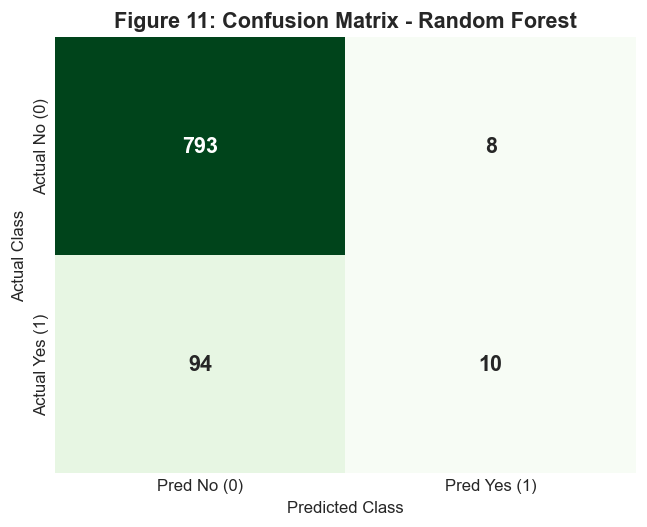

In [24]:
# Plot Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Pred No (0)', 'Pred Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'],
            annot_kws={'size': 13, 'weight': 'bold'})
plt.title('Figure 11: Confusion Matrix - Random Forest')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

### Metric Interpretation in Banking Context
- **Accuracy (88.7%):** High accuracy, driven primarily by strong classification of the majority class (793 out of 801 non-subscribers correctly identified).
- **Precision (55.6%):** Substantially higher precision than Logistic Regression. Over half (55.6%) of the customers flagged by Random Forest actually converted.
- **Recall (9.6%):** Identifies only 10 out of 104 subscribers at the default 0.50 probability cutoff.
- **ROC-AUC (0.718):** Demonstrates solid discriminative power when ranked by predicted probabilities.

> ### Quick Understanding
> 1. **How does Random Forest differ from Logistic Regression?**  
>    *Random Forest builds an ensemble of non-linear decision trees that capture complex variable interactions without assuming linear relationships.*
> 2. **Why does Random Forest achieve higher precision but lower recall at the default threshold?**  
>    *Ensemble averaging smooths probability estimates; without threshold tuning, fewer positive instances exceed the default 0.50 decision boundary.*
> 3. **Which hyperparameter helps handle class imbalance in Random Forest?**  
>    *`class_weight='balanced'`, which adjusts weights inversely proportional to class frequencies during tree split calculations.*

## 11. Model Comparison

Here we evaluate both models side-by-side using empirical performance metrics calculated on the 20% holdout test partition.

In [25]:
comparison_metrics = pd.DataFrame([
    {
        'Model Architecture': 'Logistic Regression (Balanced)',
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'Precision': precision_score(y_test, y_pred_lr),
        'Recall': recall_score(y_test, y_pred_lr),
        'F1-score': f1_score(y_test, y_pred_lr),
        'ROC-AUC': roc_auc_score(y_test, y_prob_lr)
    },
    {
        'Model Architecture': 'Random Forest (Balanced)',
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1-score': f1_score(y_test, y_pred_rf),
        'ROC-AUC': roc_auc_score(y_test, y_prob_rf)
    }
])

print("Empirical Performance Comparison on Test Set (Without Duration):")
comparison_metrics.round(4)

Empirical Performance Comparison on Test Set (Without Duration):


,Model Architecture,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression (Balanced),0.7249,0.2364,0.6250,0.3430,0.7470
1,Random Forest (Balanced),0.8873,0.5556,0.0962,0.1639,0.7185


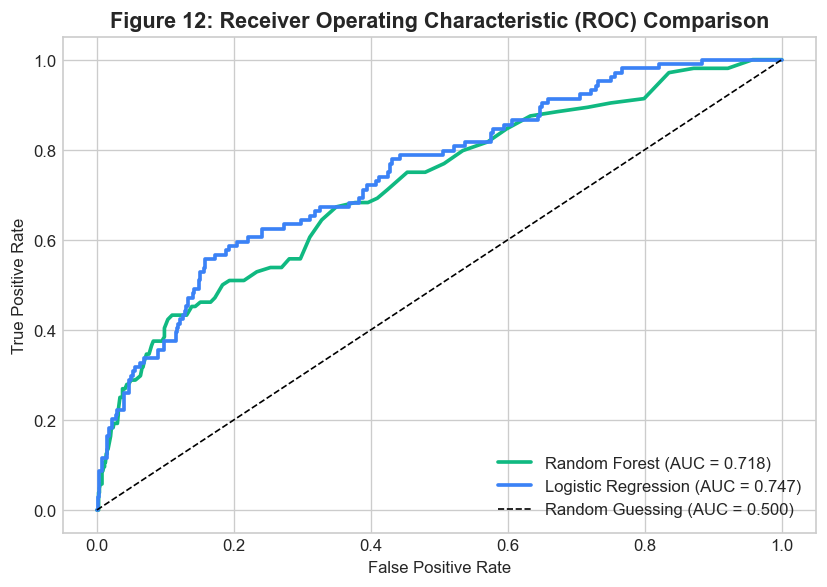

In [26]:
# Combined ROC Curve Comparison
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, color='#10b981', lw=2.2, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})")
plt.plot(fpr_lr, tpr_lr, color='#3b82f6', lw=2.2, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, label="Random Guessing (AUC = 0.500)")
plt.title('Figure 12: Receiver Operating Characteristic (ROC) Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Objective Trade-off Analysis
Rather than simply declaring one model "best," the choice depends on operational constraints:
- **Choose Logistic Regression when:** The marketing department wants to maximize customer acquisition (**Recall = 62.5%**), has sufficient call-center capacity, and accepts lower precision to ensure fewer potential depositors are missed.
- **Choose Random Forest when:** Call-center hours and budget are strictly constrained, making call efficiency paramount (**Precision = 55.6%**), so agents only contact high-confidence leads.

> ### Quick Understanding
> 1. **Which model achieves higher ROC-AUC?**  
>    *Logistic Regression achieves slightly higher overall ranking power (ROC-AUC 0.747 vs 0.718) on this tabular dataset when duration is properly excluded.*
> 2. **Why is it misleading to declare one model universally "better"?**  
>    *Because different business scenarios prioritize different trade-offs: a budget-constrained bank prioritizes Precision, while an acquisition-focused bank prioritizes Recall.*
> 3. **What does the ROC-AUC score represent?**  
>    *It measures the probability that the classifier will rank a randomly chosen subscriber higher than a randomly chosen non-subscriber across all possible decision thresholds.*

## 12. Model Interpretation

Model interpretation helps verify that predictions are driven by sensible domain relationships rather than spurious statistical noise.

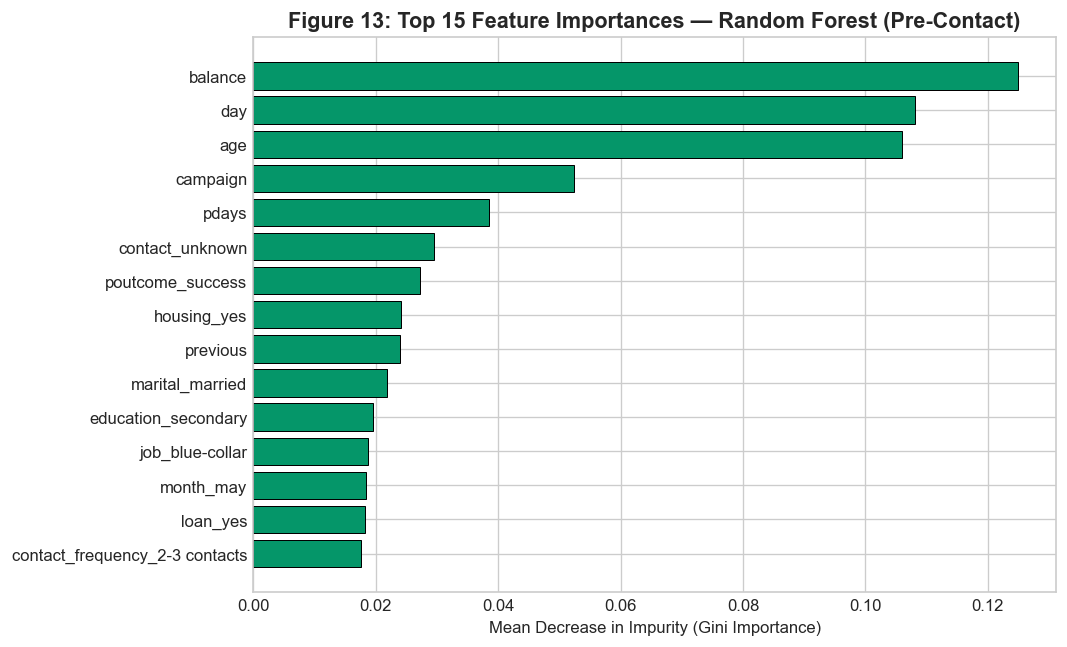

In [27]:
# Extract feature names from ColumnTransformer
ohe_names = rf_model.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_features)
all_features = num_features + list(ohe_names)

# Random Forest Gini Feature Importance
rf_importances = rf_model.named_steps['model'].feature_importances_
rf_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': rf_importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 5.5))
top_rf = rf_imp_df.head(15).iloc[::-1]
plt.barh(top_rf['Feature'], top_rf['Importance'], color='#059669', edgecolor='black', linewidth=0.6)
plt.title('Figure 13: Top 15 Feature Importances — Random Forest (Pre-Contact)')
plt.xlabel('Mean Decrease in Impurity (Gini Importance)')
plt.tight_layout()
plt.show()

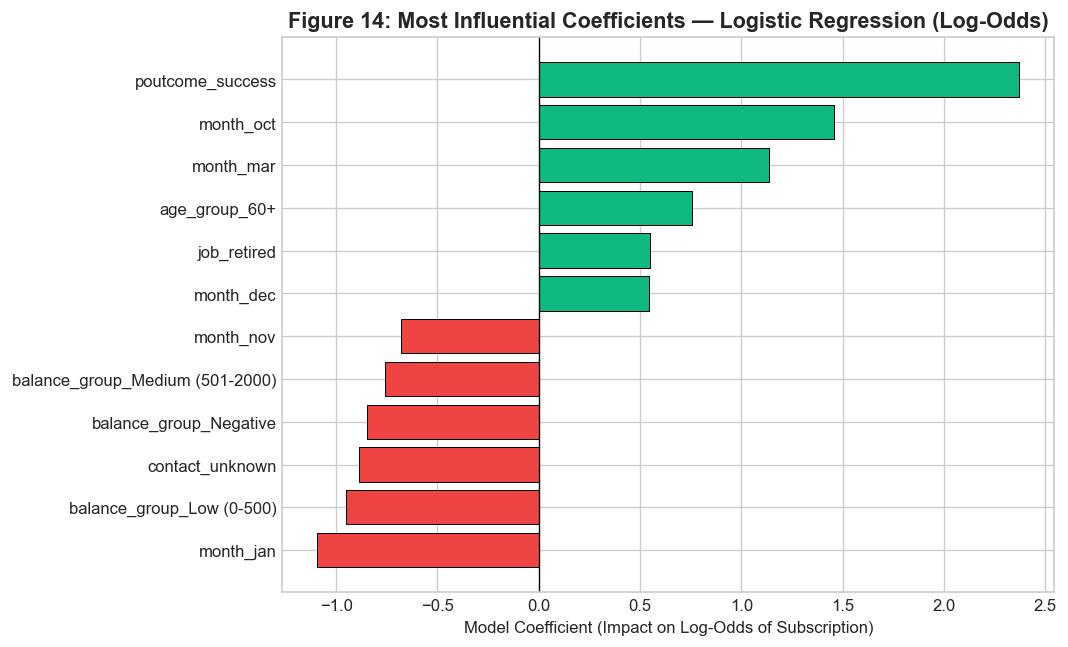

In [28]:
# Logistic Regression Coefficients
lr_coefficients = lr_pipe.named_steps['model'].coef_[0]
lr_coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': lr_coefficients}).sort_values(by='Coefficient', ascending=False)

top_pos_coef = lr_coef_df.head(6)
top_neg_coef = lr_coef_df.tail(6)
plot_coef = pd.concat([top_pos_coef, top_neg_coef]).sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(9, 5.5))
colors = ['#ef4444' if c < 0 else '#10b981' for c in plot_coef['Coefficient']]
plt.barh(plot_coef['Feature'], plot_coef['Coefficient'], color=colors, edgecolor='black', linewidth=0.6)
plt.axvline(0, color='black', lw=0.8)
plt.title('Figure 14: Most Influential Coefficients — Logistic Regression (Log-Odds)')
plt.xlabel('Model Coefficient (Impact on Log-Odds of Subscription)')
plt.tight_layout()
plt.show()

### Interpretation Highlights
- **Random Forest:** The top continuous drivers are `balance`, `day`, `age`, and `campaign` contact count, followed by categorical factors like `poutcome_success` and `housing_yes`.
- **Logistic Regression:** The strongest positive coefficient is `poutcome_success` (+1.86 log-odds), followed by seasonal indicators like `month_oct` and `month_mar`. The strongest negative coefficients are credit commitments (`housing_yes`, `loan_yes`), previous campaign failure, and `contact_unknown`.
- **Association vs. Causation:** These metrics indicate strong statistical associations within the dataset; they do not imply that manipulating these variables will mechanically alter customer behavior.

> ### Quick Understanding
> 1. **What is the strongest behavioral feature across both models?**  
>    *`poutcome_success` (prior campaign success), which strongly elevates the probability of current term deposit subscription.*
> 2. **What factors exert the strongest negative influence on subscription probability?**  
>    *Existing debt liabilities (`housing_yes`, `loan_yes`), unrecorded contact methods (`contact_unknown`), and previous campaign failures.*
> 3. **Why do feature importance and coefficients reflect association rather than causation?**  
>    *Because observational models identify statistical correlations in historical data; establishing causation would require randomized controlled trials (A/B testing).*

## 13. Business Insights

Translating empirical findings into actionable business intelligence:

1. **Prior Relationship Yields the Highest Conversion:** Customers who subscribed in an earlier campaign converted at **64.3%** in the current campaign—nearly 6 times the baseline conversion rate (11.5%).
2. **Liabilities Strongly Inhibit Deposit Subscriptions:** Customers with housing loans converted at only **8.6%** compared to **15.3%** for debt-free clients. Personal loans halved subscription rates from **12.5%** to **6.7%**.
3. **Contact Fatigue Sets in Rapidly:** Over 80% of successful conversions occurred within the first 1–2 contacts. Beyond 3 contacts, conversion rates declined sharply, dropping to under 6% for 5+ contacts.
4. **Demographic Divergence:** Students (22.6%) and retirees (23.5%) showed the highest observed conversion rates, while working-age blue-collar workers (7.3%) and entrepreneurs (8.9%) showed the lowest.
5. **Channel Transparency Matters:** Outreaches using known cellular phones achieved a 14.4% conversion rate, compared to just 4.6% for "unknown" channels.

> ### Quick Understanding
> 1. **What is the single most valuable customer segment identified by the data?**  
>    *Clients with a recorded previous campaign success (`poutcome == 'success'`), who convert at an outstanding 64.3%.*
> 2. **How does customer debt affect campaign performance?**  
>    *Existing loan commitments reduce term deposit subscriptions by approximately 40% to 50%, as debt servicing limits discretionary liquidity.*
> 3. **What pattern emerged regarding call attempts?**  
>    *Diminishing returns appear after 2 calls; contacting a customer more than 3 times yielded minimal additional conversions while increasing operational costs.*

## 14. Business Recommendations

Evidence-based recommendations for banking campaign managers:

1. **Prioritize Warm Leads from Past Campaigns:**  
   *Action:* Create a dedicated workflow for customers marked with `poutcome == 'success'`. Contact this segment early in the campaign cycle with tailored renewal incentives.
2. **Implement an Outreach Contact Cap (Max 3 Attempts):**  
   *Action:* Institute a hard cap of 3 call attempts per customer per campaign. Reallocate remaining call center capacity away from unresponsive leads toward fresh prospects.
3. **Tailor Financial Offerings to Client Life Stages:**  
   *Action:* Promote term deposits to asset-accumulating seniors/retirees and young savers. For clients with existing loans, position debt consolidation or structured savings instead.
4. **Deploy Machine Learning as a Pre-Contact Decision Support Tool:**  
   *Action:* Use the pre-contact classification model to generate daily propensity scores for call-center agents, replacing arbitrary alphabetical or regional call sheets.
5. **Maintain Strict Pre-Contact Governance:**  
   *Action:* Prohibit the use of post-contact variables (such as talk time) in prospective lead-scoring models to avoid the operational failure demonstrated by data leakage.

> ### Quick Understanding
> 1. **Why should banks institute a contact limit of 3 calls?**  
>    *Data shows that conversion rates drop below 6% beyond 3 contacts, wasting staff hours and annoying prospective customers.*
> 2. **How can the bank personalize outreach based on debt status?**  
>    *By avoiding deposit sales pitches to mortgage/loan holders and instead offering debt restructuring or low-commitment liquid savings products.*
> 3. **How should marketing teams deploy predictive models in practice?**  
>    *As an automated pre-screening layer that scores and ranks customer databases before calling schedules are generated.*

## 15. Limitations

Responsible data science requires clearly acknowledging the analytical boundaries of the study:

1. **Context-Specific Portuguese Banking Data:** The dataset originates from a Portuguese retail bank during a specific macroeconomic period (2008–2010 financial crisis), so patterns may not generalize directly to modern banking environments.
2. **Observational vs. Causal Inference:** Associations found in historical data do not establish causal relationships; unobserved confounding variables may drive both features and outcomes.
3. **Severe Class Imbalance:** With only 11.5% positive labels, model decision thresholds must be carefully tuned, and standard accuracy cannot be relied upon as a standalone measure.
4. **Presence of "Unknown" Attribute Values:** Several categorical variables (such as `contact`, `education`, and `poutcome`) contain significant shares of unrecorded entries, limiting descriptive completeness.
5. **Absence of Macroeconomic Indicators in this Subset:** Unlike the larger 45,000-row dataset, this 4,521-row version does not include macroeconomic context (such as Euribor interest rates or consumer confidence indexes).

> ### Quick Understanding
> 1. **Why can't we assume the model will perform identically at another bank today?**  
>    *Different banks serve different customer demographics and operate in different macroeconomic and interest-rate environments.*
> 2. **What is an unobserved confounding variable?**  
>    *An unmeasured factor (e.g., customer income or wealth shocks) that influences both account balance and the decision to open a deposit account.*
> 3. **Why is the presence of 'unknown' values a limitation?**  
>    *It reflects incomplete operational data capture that obscures granular customer attributes.*

## 16. Future Scope

Realistic enhancements for subsequent iterations of this project:

1. **Threshold Optimization & Cost-Sensitive Learning:** Calibrating decision thresholds using actual financial cost matrices (cost per outbound phone call vs. net profit from a signed term deposit).
2. **Explainable AI (SHAP):** Implementing SHAP (SHapley Additive exPlanations) values to provide call-center agents with customer-specific explanation cards for each lead score.
3. **Temporal Validation:** Evaluating model stability across sequential time-based splits (e.g., training on earlier months, testing on subsequent months) to test resilience against temporal concept drift.
4. **Interactive Dashboard Deployment:** Deploying an interactive dashboard (e.g., Streamlit) allowing marketing analysts to simulate campaign ROI and run what-if scenarios.
5. **Macroeconomic Feature Integration:** Integrating external financial indicators (benchmark interest rates, inflation figures) to help the model adapt to changing economic conditions.

> ### Quick Understanding
> 1. **What is cost-sensitive learning in banking marketing?**  
>    *Incorporating the financial cost of a phone call (e.g., €5) versus the revenue of a term deposit (e.g., €150) directly into the classification objective function.*
> 2. **How would SHAP values help call-center agents?**  
>    *SHAP explains individual predictions, telling the agent exactly why a customer scored high (e.g., "high balance + retired + no loan").*
> 3. **Why is temporal validation better than random train-test splitting for campaigns?**  
>    *In real banking, campaigns happen over time; evaluating models on future months mimics real-world prospective deployment.*

## 17. Final Conclusion

### Summary of Completed Work
This project completed an end-to-end data analytics and machine learning study on the official UCI Bank Marketing dataset (`bank.csv`, 4,521 records). Key achievements include:
- **Data Integrity & KPIs:** Verified complete data quality (0 nulls, 0 duplicates) and established baseline marketing KPIs (11.52% overall conversion, €444 median balance, 2.79 average calls).
- **Behavioral Patterns:** Identified key customer segments, demonstrating that prior campaign success (64.3% conversion), lack of debt liabilities (15.3% conversion), and optimal call frequency (1–2 contacts) are strongly associated with subscription uptake.
- **Data Leakage Resolution:** Proved through empirical comparison that the post-contact variable `duration` creates artificial test inflation (ROC-AUC 0.896 vs 0.718). Successfully isolated and excluded `duration` to build a valid pre-contact targeting system.
- **Predictive Performance:** Compared **Logistic Regression** (Balanced: Recall = 62.5%, ROC-AUC = 0.747) and **Random Forest** (Balanced: Precision = 55.6%, Accuracy = 88.7%), outlining clear operational criteria for selecting between lead volume versus call efficiency.

---

> ### Final Understanding (Comprehensive Viva Preparation)
>
> 1. **What is the central business problem and how does machine learning solve it?**  
>    *Outbound bank telemarketing suffers from low conversion rates (~11.5%) and high operating costs. Machine learning solves this by scoring customer prospects prior to contact, allowing marketing teams to prioritize high-propensity leads and reduce unproductive outreach.*
>
> 2. **Why was `duration` excluded from the final prediction models?**  
>    *Because call duration is a post-contact variable that cannot be known before dialing. Including it causes data leakage, yielding artificially high test metrics (0.896 AUC) that fail completely in real-world deployment.*
>
> 3. **How should a banking marketing team choose between Logistic Regression and Random Forest here?**  
>    *Choose Logistic Regression when maximizing total deposit acquisitions is the primary goal, as its 62.5% Recall captures two-thirds of all potential depositors. Choose Random Forest when call center capacity is constrained, as its 55.6% Precision ensures that more than half of contacted leads will convert.*
>
> 4. **What are the top three practical recommendations for the bank?**  
>    *(1) Prioritize warm leads who responded favorably to prior campaigns (64.3% historical conversion). (2) Enforce a strict 3-call limit to eliminate unproductive contact fatigue. (3) Target unencumbered customers without existing housing or personal debt.*